In [38]:
# import data
import os
from datasets import load_dataset

# basic
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import re

# pre-processing, training
from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder


# PART 1. Data Pre-processing

#### 1. Load data

In [3]:
# load data from Hugging face
ds = load_dataset("aneesarom/Food-Delivery")

# convert to dataframe
df = pd.concat([ds['train'].to_pandas(), ds['test'].to_pandas()], ignore_index=True)

# sanity check
print(df.shape)
df.head()

(45584, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0x6bbb,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,17
1,0x190a,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,33
2,0x120c,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0,No,NaN,20
3,0x6016,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitian,27
4,0x9ca0,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitian,26


#### 2. Format Conversion

In [4]:
# 1. check all columns info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  str    
 1   Delivery_person_ID           45584 non-null  str    
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  str    
 9   Time_Orderd                  43853 non-null  str    
 10  Time_Order_picked            45584 non-null  str    
 11  Weather_conditions           44968 non-null  str    
 12  Road_traffic_density         44983 non-null  str    
 13  Vehicle_condition          

In [5]:
# 2. Convert date format
# Convert Order_Date (format: DD-MM-YYYY) to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y', errors='coerce')

# Check how many failed to convert (became NaT)
print(f"Order_Date NaT count: {df['Order_Date'].isnull().sum()}")

Order_Date NaT count: 0


In [6]:
# 3. Convert time format
# Check if any time format is out of pattern HH:MM
pattern = re.compile(r'^\d{2}:\d{2}$')

def check_suspicious_times(df, column):
    value_counts = df[column].value_counts(dropna=False)
    suspicious_counts = value_counts[~value_counts.index.astype(str).str.match(pattern)]
    print(f"--- {column} ---")
    print(suspicious_counts)
    print(f"Total suspicious rows: {suspicious_counts.sum()}\n")
    return suspicious_counts

check_suspicious_times(df, 'Time_Orderd')
check_suspicious_times(df, 'Time_Order_picked')

--- Time_Orderd ---
Time_Orderd
NaN            1731
0.833333333     449
1               430
0.791666667     424
0.958333333     422
0.875           409
0.916666667     404
0.75            402
0.416666667     211
0.458333333     193
0.5             189
0.375           177
0.625            86
0.541666667      79
0.583333333      74
0.708333333      66
0.666666667      53
Name: count, dtype: int64
Total suspicious rows: 5799

--- Time_Order_picked ---
Time_Order_picked
0.833333333    452
1              440
24:05:00       435
0.916666667    430
0.75           422
0.875          416
0.958333333    411
0.791666667    403
24:10:00       280
0.375          201
0.416666667    194
0.5            188
24:15:00       165
0.458333333    148
0.625          100
0.666666667     91
0.541666667     83
0.583333333     82
0.708333333     66
Name: count, dtype: int64
Total suspicious rows: 5007



Time_Order_picked
0.833333333    452
1              440
24:05:00       435
0.916666667    430
0.75           422
0.875          416
0.958333333    411
0.791666667    403
24:10:00       280
0.375          201
0.416666667    194
0.5            188
24:15:00       165
0.458333333    148
0.625          100
0.666666667     91
0.541666667     83
0.583333333     82
0.708333333     66
Name: count, dtype: int64

In [7]:
# function to parse time 
def parse_time_value(val):
    if pd.isnull(val):
        return pd.NaT
    
    if isinstance(val, str):
        val = val.strip()
        if val.lower() == 'nan' or val == '':
            return pd.NaT
    
    # Try parsing as Excel-style fraction of a day (numeric), valid range [0, 1]
    try:
        frac = float(val)
        if 0 <= frac <= 1:
            total_seconds = round(frac * 24 * 3600)
            rollover_days = total_seconds // (24 * 3600)  # 1 if frac == 1.0, else 0
            hours = (total_seconds // 3600) % 24
            minutes = (total_seconds % 3600) // 60
            base = pd.to_datetime(f"{hours:02d}:{minutes:02d}", format='%H:%M', errors='coerce')
            return base + pd.Timedelta(days=rollover_days)
        else:
            return pd.NaT
    except (ValueError, TypeError):
        pass
    
    # Try HH:MM:SS strings with hour possibly = 24 (roll over to next day, 00:xx)
    match = re.match(r'^(\d{2}):(\d{2}):(\d{2})$', val)
    if match:
        h, m, s = int(match.group(1)), int(match.group(2)), int(match.group(3))
        rollover_days = h // 24  # 1 if h == 24, else 0
        h = h % 24
        base = pd.to_datetime(f"{h:02d}:{m:02d}", format='%H:%M', errors='coerce')
        return base + pd.Timedelta(days=rollover_days)
    
    # Otherwise, try parsing as a normal HH:MM string
    return pd.to_datetime(val, format='%H:%M', errors='coerce')

df['Time_Ordered'] = df['Time_Orderd'].apply(parse_time_value)
df['Time_Order_Picked'] = df['Time_Order_picked'].apply(parse_time_value)

print(f"Time_Ordered NaT count: {df['Time_Ordered'].isnull().sum()}")
print(f"Time_Order_Picked NaT count: {df['Time_Order_Picked'].isnull().sum()}")

Time_Ordered NaT count: 1731
Time_Order_Picked NaT count: 0


#### 3. Missing values

In [8]:
# 1. Check overall NA counts first
# Replace any NaN string to NA
df = df.replace('NaN', np.nan)

# Check missing value counts
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
Time_Ordered                   1731
Time_Order_Picked                 0
dtype: int64

In [ ]:
# 2. check values of string columns
# cols = ['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']
# for x in cols:
#     print(f"--- {x} ---")
#     print(df[x].value_counts(dropna=False).to_string())
#     print()

# print(df['Weather_conditions'].value_counts(dropna=False).to_string())
# print(df['Road_traffic_density'].value_counts(dropna=False).to_string())
# print(df['Type_of_order'].value_counts(dropna=False).to_string())
# print(df['Type_of_vehicle'].value_counts(dropna=False).to_string())
# print(df['Festival'].value_counts(dropna=False).to_string())
# print(df['City'].value_counts(dropna=False).to_string())

In [9]:
# 3. Remove missing values
# Remove missing values
df_clean = df.dropna()

# sanity check
print(f"Original shape: {df.shape}")
print(f"After dropping missing values: {df_clean.shape}")

# print all columns info
df_clean.info()

Original shape: (45584, 22)
After dropping missing values: (41359, 22)
<class 'pandas.DataFrame'>
Index: 41359 entries, 0 to 45583
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           41359 non-null  str           
 1   Delivery_person_ID           41359 non-null  str           
 2   Delivery_person_Age          41359 non-null  float64       
 3   Delivery_person_Ratings      41359 non-null  float64       
 4   Restaurant_latitude          41359 non-null  float64       
 5   Restaurant_longitude         41359 non-null  float64       
 6   Delivery_location_latitude   41359 non-null  float64       
 7   Delivery_location_longitude  41359 non-null  float64       
 8   Order_Date                   41359 non-null  datetime64[us]
 9   Time_Orderd                  41359 non-null  str           
 10  Time_Order_picked            41359 non-null  str   

In [10]:
# Check duplicates
print(f"Number of duplicate rows: {df_clean.duplicated().sum()}")

Number of duplicate rows: 0


#### 4. Feature Engineering

In [11]:
# 1. Calculate distance
# Function to calculate Haversine distance
def haversine_np(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # km

# Distance in km
df_clean['Distance_km'] = haversine_np(df_clean['Restaurant_latitude'],
                                         df_clean['Restaurant_longitude'],
                                         df_clean['Delivery_location_latitude'],
                                         df_clean['Delivery_location_longitude'])

# sanity check
df_clean['Distance_km'].describe()

count    41359.000000
mean        26.915498
std        298.814439
min          1.465067
25%          4.663601
50%          9.268782
75%         13.735954
max       6884.726399
Name: Distance_km, dtype: float64

In [12]:
# 2. Calculate preparation in minutes
# calculate prep time
df_clean['Prep_time_min'] = (
    df_clean['Time_Order_Picked'] - df_clean['Time_Ordered']
    ).dt.total_seconds() / 60

# sanity check
df_clean['Prep_time_min'].describe()

count    41359.000000
mean         9.988999
std          4.086094
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: Prep_time_min, dtype: float64

#### 5. Data Split

In [13]:
# target
y = df_clean['Time_taken (min)']

# X
X = df_clean.drop(columns=['ID',
                            'Delivery_person_ID',
                            'Order_Date',
                            'Time_Orderd',
                            'Time_Order_picked',
                            'Restaurant_latitude',
                            'Restaurant_longitude',
                            'Delivery_location_latitude',
                            'Delivery_location_longitude',
                            'Time_taken (min)',
                            'Time_Ordered',
                            'Time_Order_Picked'])

# sanity check
print('Target:', y.shape)
print('No of features:', X.shape)

Target: (41359,)
No of features: (41359, 12)


In [14]:
# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 33087
Test size: 8272


#### 6. Data Patterns

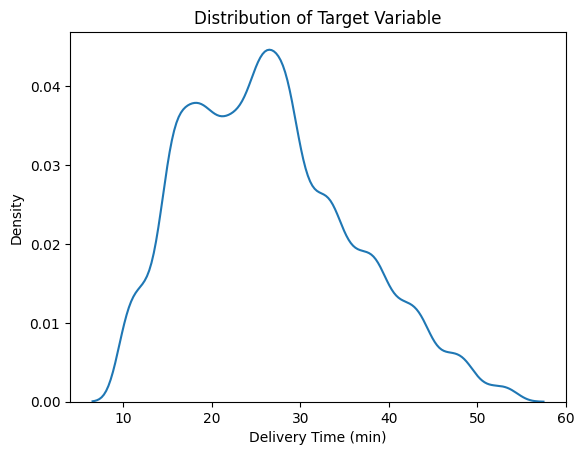

In [15]:
# 1. Distribution of target variable
sns.kdeplot(y_train)
plt.xlabel('Delivery Time (min)')
plt.title('Distribution of Target Variable')
plt.show()

In [42]:
# features
feature_labels = X_train.columns
cat_cols = ['Weather_conditions', 'Road_traffic_density', 'Vehicle_condition',
            'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 
            'Festival', 'City']
num_cols = [x for x in feature_labels if x not in cat_cols]

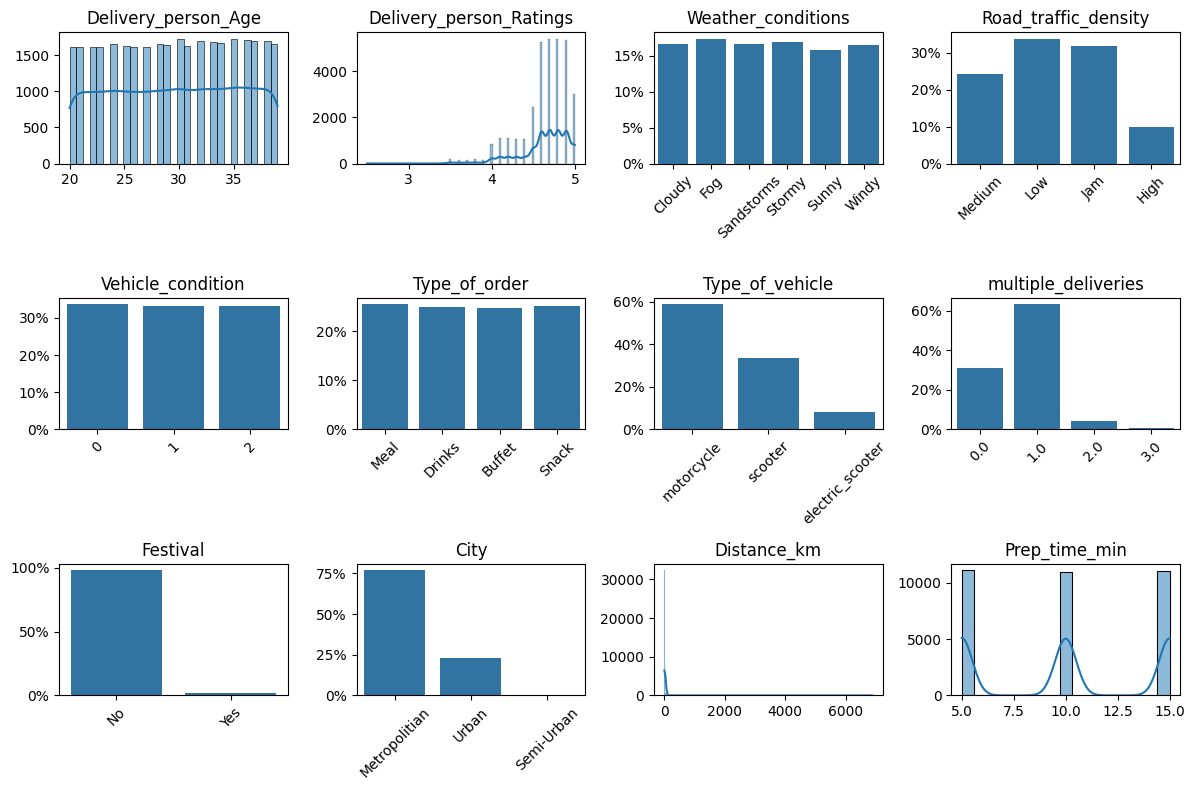

In [43]:
# 2. Distribution of feature variables
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 8))
axes = axes.flatten()

# histogram: numerical + count plots: categorical
for i, col in enumerate(feature_labels):
  if col in cat_cols:
    sns.countplot(x=col, data=X_train, ax=axes[i], stat='percent')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].yaxis.set_major_formatter(PercentFormatter(decimals=0))
  else:
    sns.histplot(X_train[col], ax=axes[i], kde=True)

  axes[i].set_title(col)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

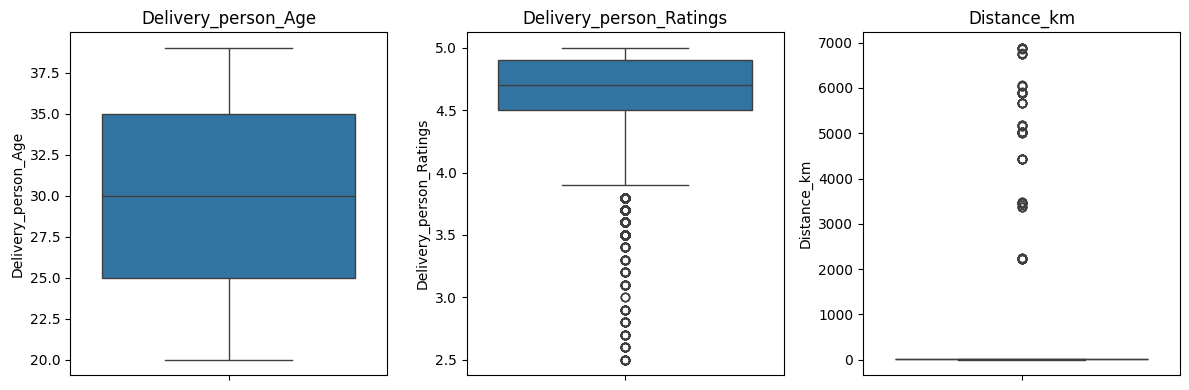

In [44]:
# Box plots of numerical
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for k, col in enumerate(num_cols):
    if col != 'Prep_time_min':
        sns.boxplot(y=X_train[col], ax=axes[k])
        axes[k].set_title(col)

plt.tight_layout()
plt.show()

#### 7. Outliers

In [19]:
# Review Distance_km
print("Basic statistics of Distance_km:")
print(X_train['Distance_km'].describe())

# Calculate mean +/- 3 std
mean = X_train['Distance_km'].mean()
std = X_train['Distance_km'].std()
print("\n\nMean +/- 3 std of Distance_km:")
print(mean - 3 * std, mean + 3 * std)

# count for outliers
print("Number of outliers (> mean+3std):", (X_train['Distance_km'] >= mean + 3 * std).sum())
print("Account for:",((X_train['Distance_km'] >= mean + 3 * std).sum() / len(X_train['Distance_km']))*100)


# IQR
Q1 = X_train['Distance_km'].quantile(0.25)
Q3 = X_train['Distance_km'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\n\nLower bound and Upper bound:")
print(lower_bound, upper_bound)

# count number of Distance_km more than upper_bound
print("Number of outliers (> upper_bound):", (X_train['Distance_km'] >= upper_bound).sum())
print("Account for:",((X_train['Distance_km'] >= upper_bound).sum() / len(X_train['Distance_km']))*100)

Basic statistics of Distance_km:
count    33087.000000
mean        26.896662
std        300.023128
min          1.465067
25%          4.663456
50%          9.220835
75%         13.682379
max       6884.726399
Name: Distance_km, dtype: float64


Mean +/- 3 std of Distance_km:
-873.1727229723627 926.9660478063591
Number of outliers (> mean+3std): 116
Account for: 0.3505908665034606


Lower bound and Upper bound:
-8.864927740322289 27.21076284656931
Number of outliers (> upper_bound): 116
Account for: 0.3505908665034606


In [20]:
# filter out outliers
idx = (X_train['Distance_km'] >= lower_bound) & (X_train['Distance_km'] <= upper_bound)

X_train_clean = X_train[idx]
y_train_clean = y_train[idx]

print(f"Removed {(~idx).sum()} outlier rows out of {len(X_train)} training rows")
print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"y_train_clean shape: {y_train_clean.shape}")

Removed 116 outlier rows out of 33087 training rows
X_train_clean shape: (32971, 12)
y_train_clean shape: (32971,)


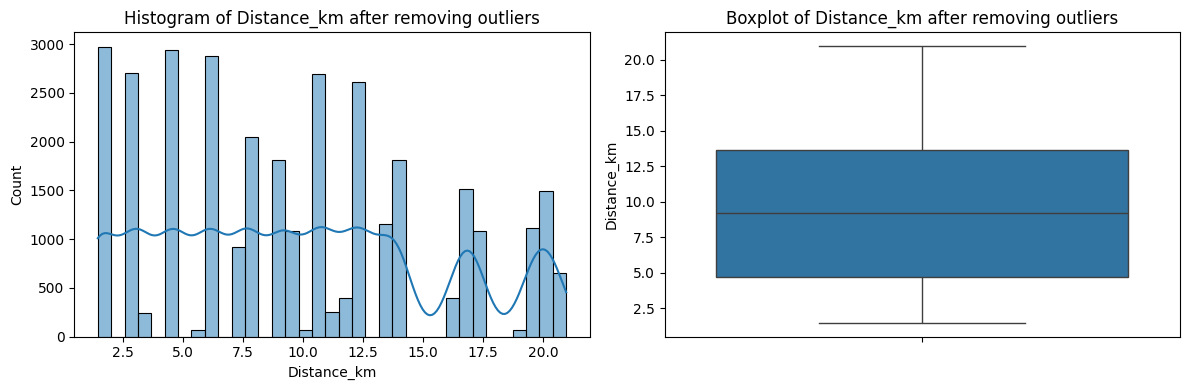

In [21]:
# Visual check: distribution
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(X_train_clean['Distance_km'], kde=True, ax=axes[0])
axes[0].set_title('Histogram of Distance_km after removing outliers')

sns.boxplot(y=X_train_clean['Distance_km'], ax=axes[1])
axes[1].set_title('Boxplot of Distance_km after removing outliers')

plt.tight_layout()
plt.show()

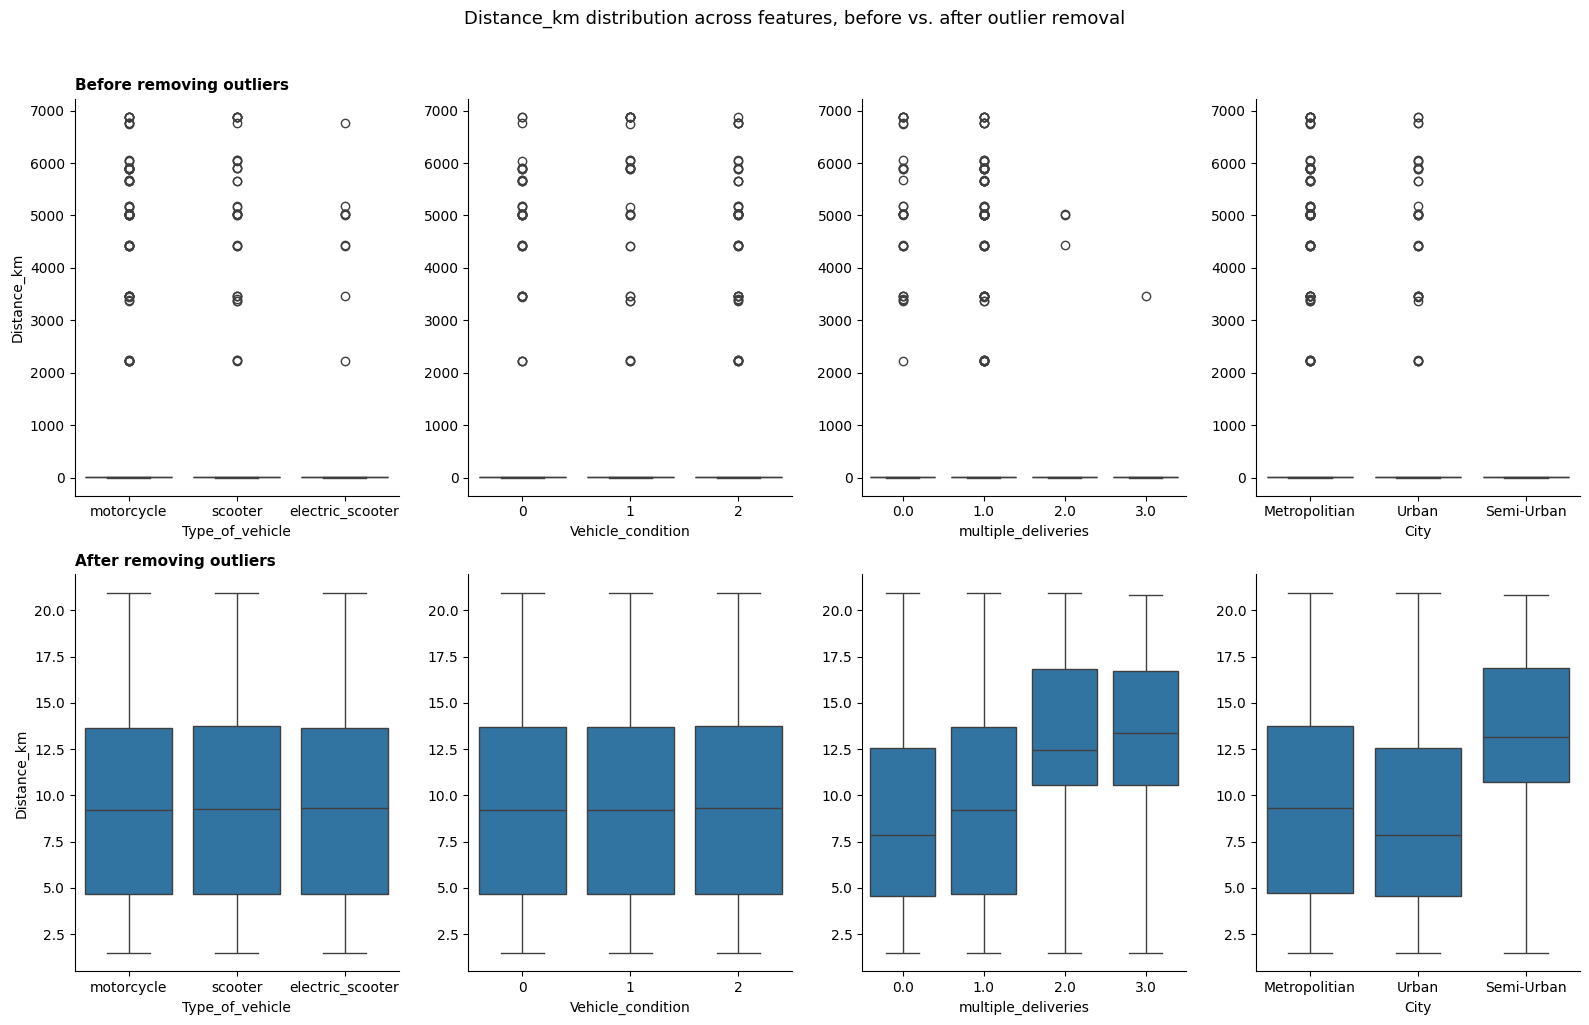

In [22]:
# Visual check: Distance_km vs. other features
fig, axes = plt.subplots(2,4, figsize=(16,10))

datasets = {'X_train': X_train, 'X_train_clean': X_train_clean}
feat_name = ['Type_of_vehicle', 'Vehicle_condition', 'multiple_deliveries', 'City']

for row, (name, df) in enumerate(datasets.items()):
    for col, feat in enumerate(feat_name):
        sns.boxplot(data=df, x=feat, y='Distance_km', ax=axes[row, col])
        if col == 0:
            axes[row, col].set_ylabel('Distance_km')
        else:
            axes[row, col].set_ylabel('')
        # remove top/right spines for a cleaner look
        axes[row, col].spines['top'].set_visible(False)
        axes[row, col].spines['right'].set_visible(False)

axes[0, 0].set_title('Before removing outliers', fontsize=11, fontweight='bold', loc='left')
axes[1, 0].set_title('After removing outliers', fontsize=11, fontweight='bold', loc='left')

fig.suptitle('Distance_km distribution across features, before vs. after outlier removal', 
             fontsize=13, y=1.02)

plt.tight_layout()
plt.show()

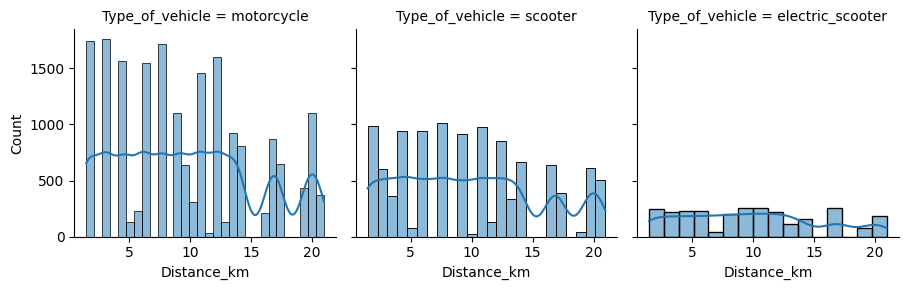

In [23]:
g = sns.FacetGrid(X_train_clean, col='Type_of_vehicle', col_wrap=4)
g.map(sns.histplot, 'Distance_km', kde=True)
plt.show()

#### 8. EDA

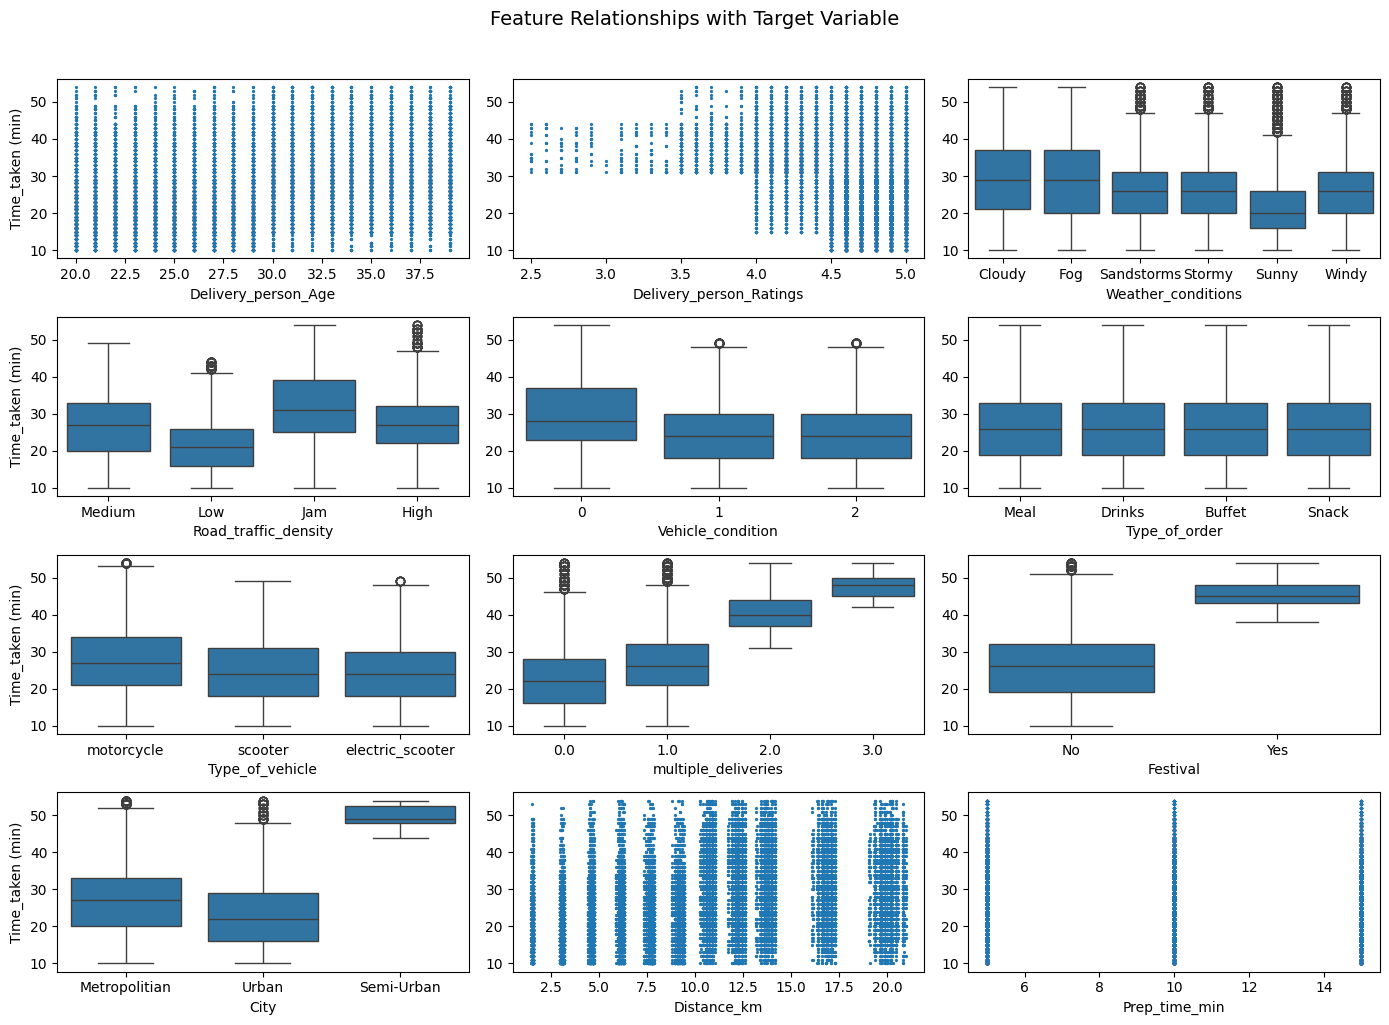

In [24]:
# 1. Cross plot: feature vs. target relationships
fig, axs = plt.subplots(4, 3, figsize=(14, 10))
axs = axs.flatten()

for k, feat in enumerate(feature_labels):

    if feat in cat_cols:
        sns.boxplot(x=X_train_clean[feat], y=y_train_clean, ax=axs[k])
    else:
        axs[k].scatter(X_train_clean[feat], y_train_clean, marker='.', s=7.0)
    
    axs[k].set_xlabel(feat)
    if k % 3 == 0:
        axs[k].set_ylabel(y_train.name)
    else:
        axs[k].set_ylabel('')

fig.suptitle('Feature Relationships with Target Variable', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

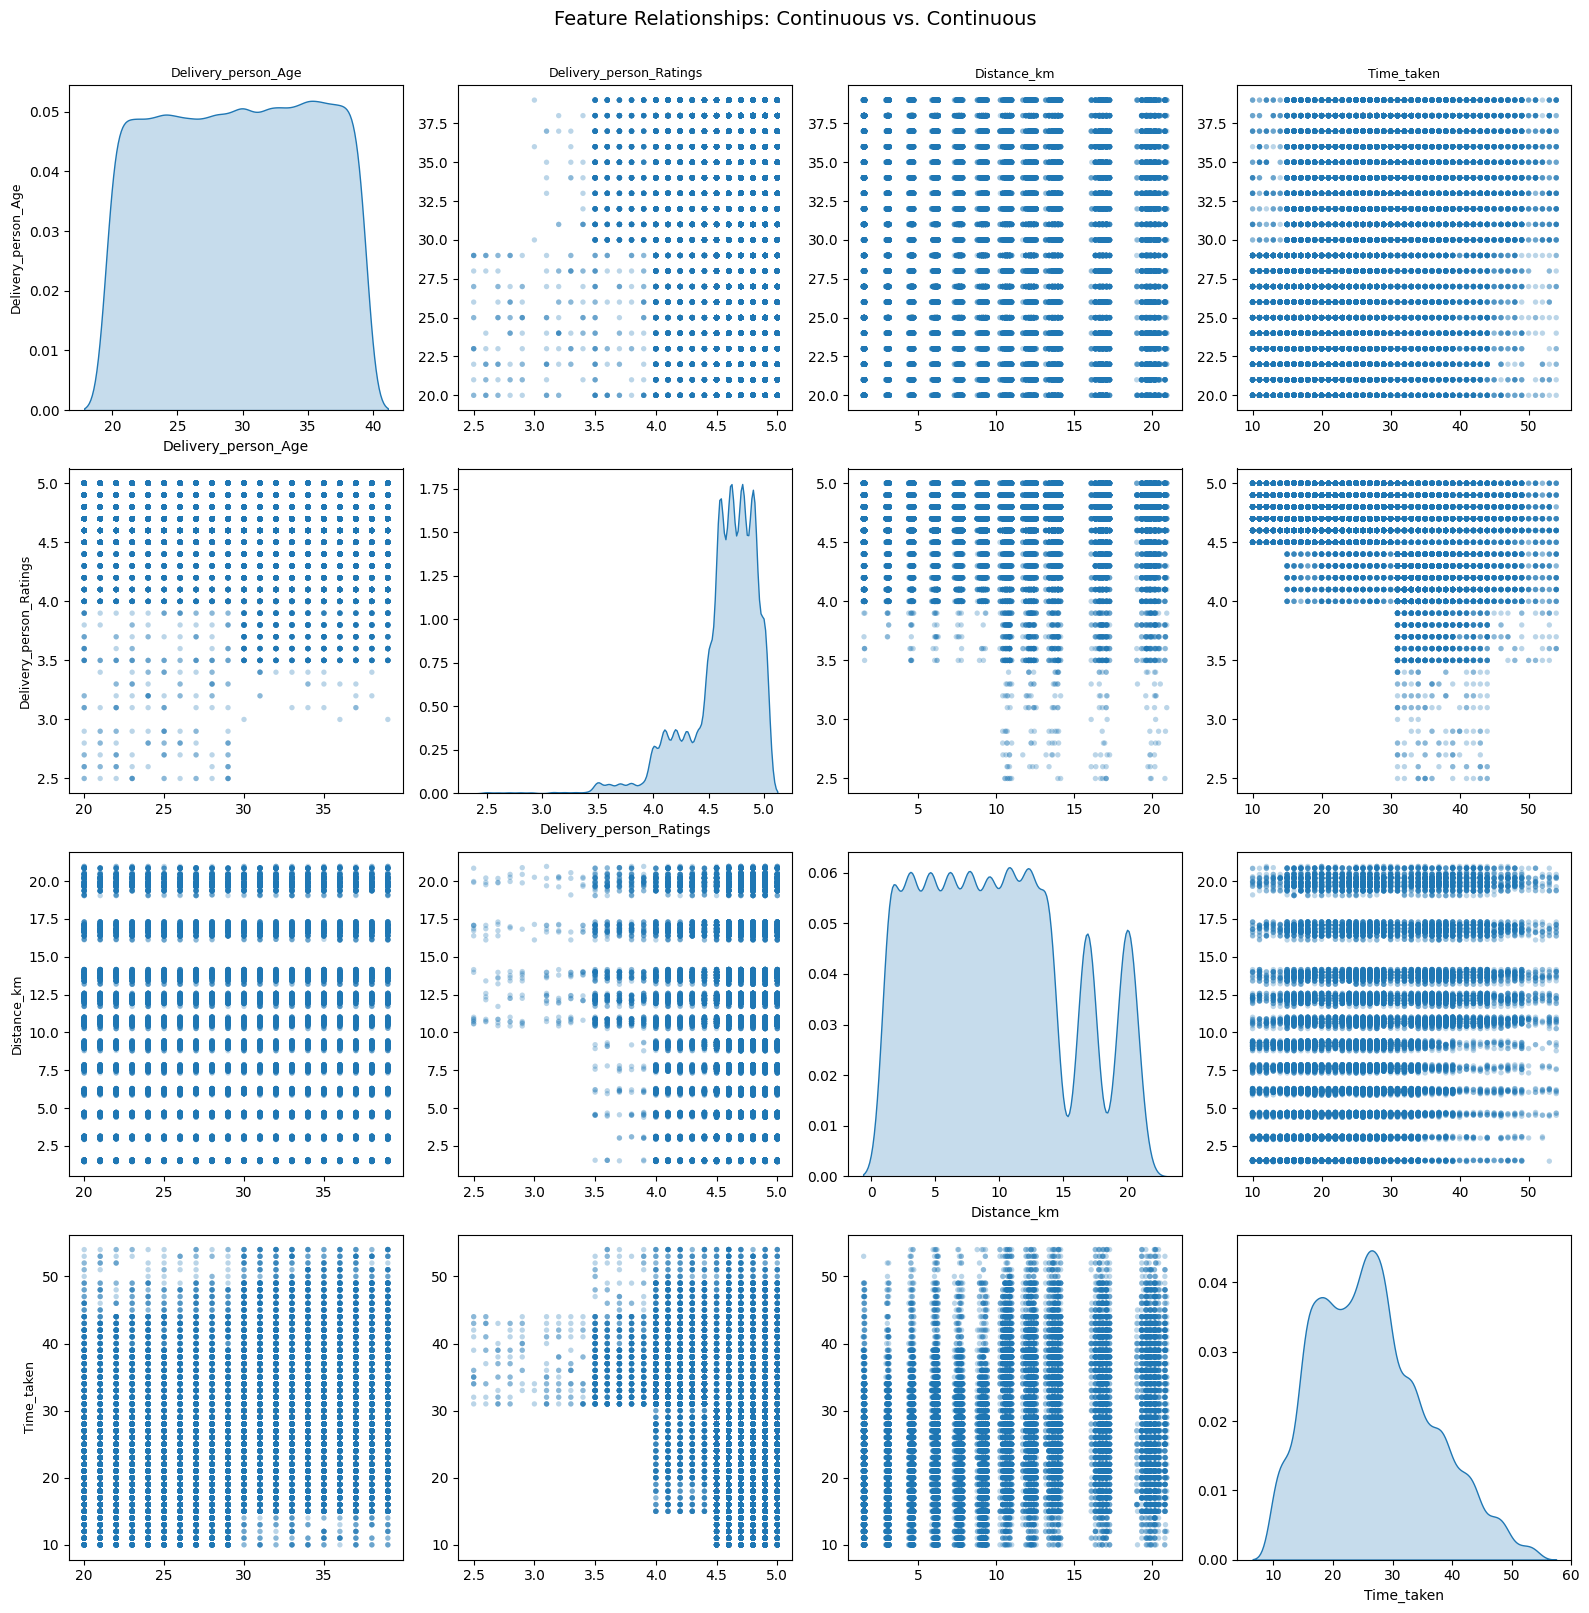

In [25]:
# 2. Pair plot: feature vs. feature relationships
# Combine X_train and y_train into one DataFrame
train_df = X_train_clean.copy()
train_df['Time_taken'] = y_train_clean

continuous_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Distance_km', 'Time_taken']
discrete_cols = ['Vehicle_condition', 'multiple_deliveries', 'Prep_time_min']
categorical_cols = ['Weather_conditions', 'Type_of_order', 'City', 'Festival', 'Road_traffic_density']

n_cont = len(continuous_cols)
n_disc = len(discrete_cols)
n_cat = len(categorical_cols)

# Pair plots
# Figure 1: Continuous vs Continuous (manual pairplot grid)
fig, axs = plt.subplots(n_cont, n_cont, figsize=(4*n_cont, 4*n_cont))

for row, rcol in enumerate(continuous_cols):
    for col, ccol in enumerate(continuous_cols):
        ax = axs[row, col]
        if row == col:
            sns.kdeplot(train_df[rcol], ax=ax, fill=True)
            ax.set_ylabel('')
        else:
            ax.scatter(train_df[ccol], train_df[rcol], alpha=0.3, s=15, edgecolor='none')
        if row == 0:
            ax.set_title(ccol, fontsize=9)
        if col == 0:
            ax.set_ylabel(rcol, fontsize=9)

fig.suptitle('Feature Relationships: Continuous vs. Continuous', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

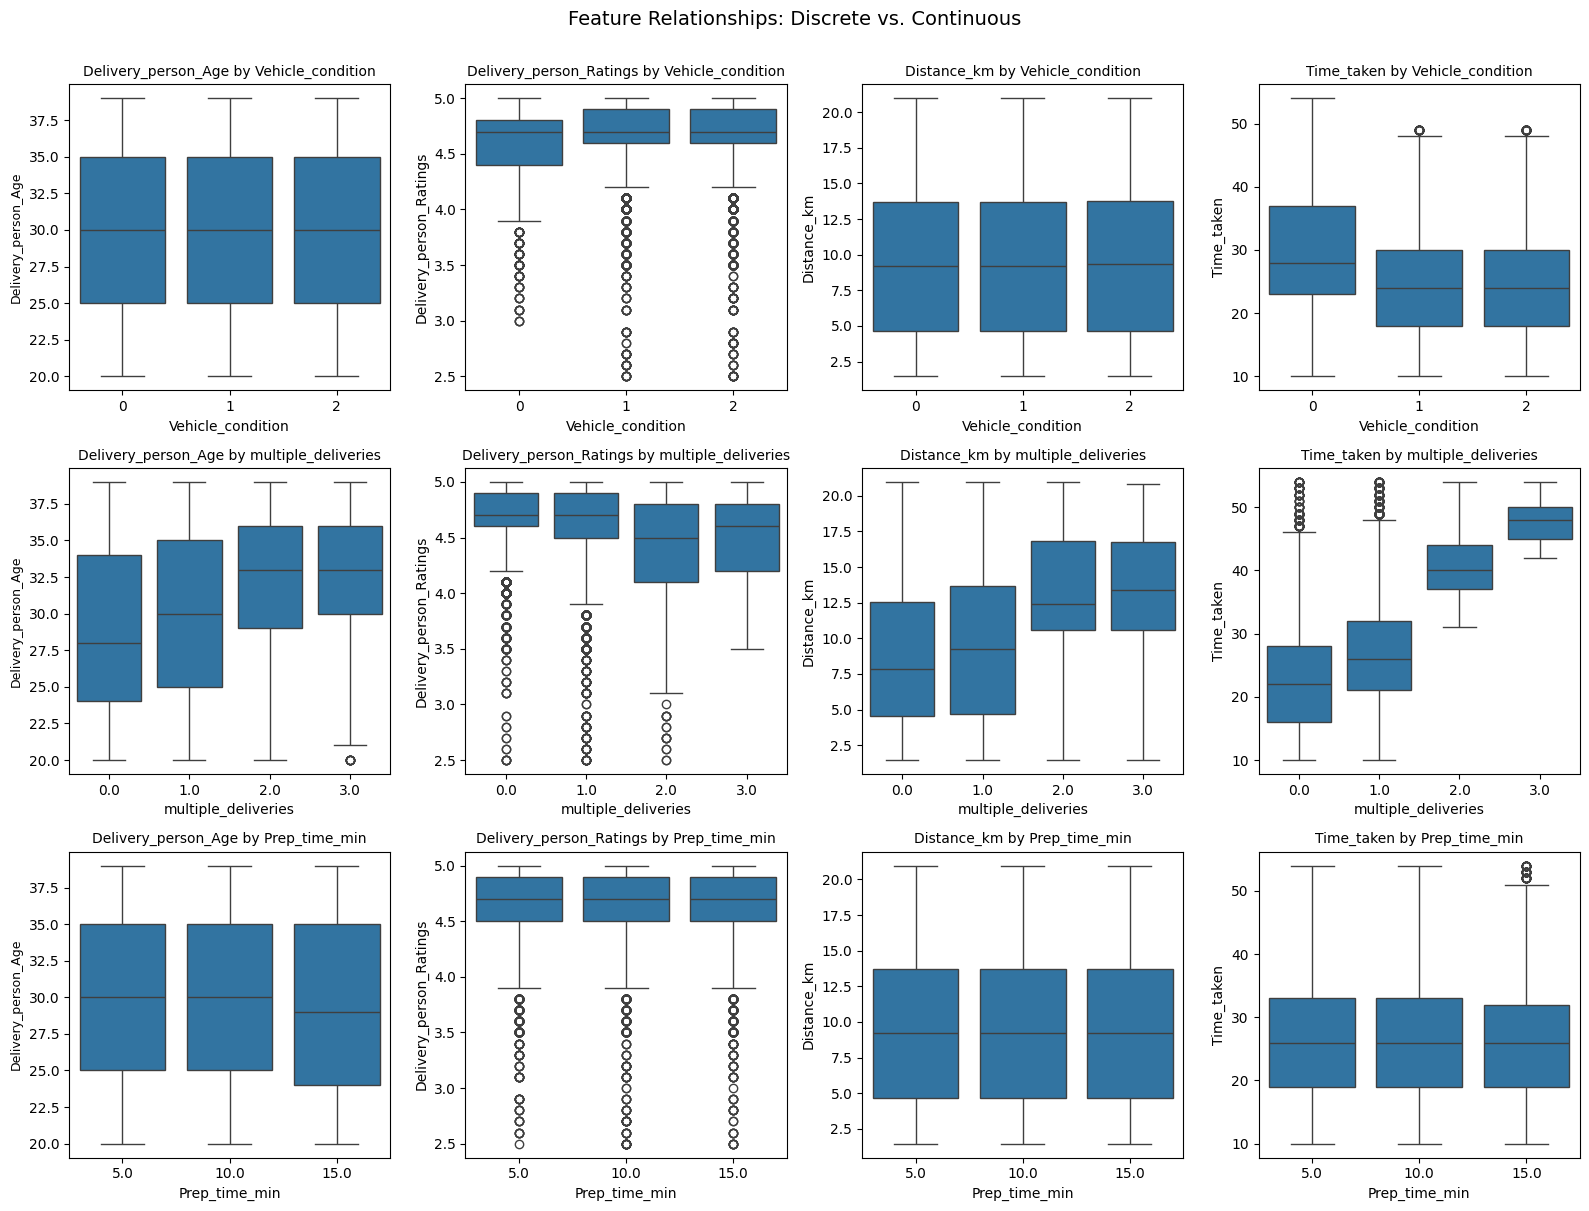

In [ ]:
# Feature relationships
# Figure 2: Discrete vs Continuous (box plots)
fig, axs = plt.subplots(n_disc, n_cont, figsize=(4*n_cont, 4*n_disc))

for i, dcol in enumerate(discrete_cols):
    for col, ccol in enumerate(continuous_cols):
        ax = axs[i, col]
        sns.boxplot(x=dcol, y=ccol, data=train_df, ax=ax)
        ax.set_title(f'{ccol} by {dcol}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{ccol}', fontsize=9)

fig.suptitle('Feature Relationships: Discrete vs. Continuous', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

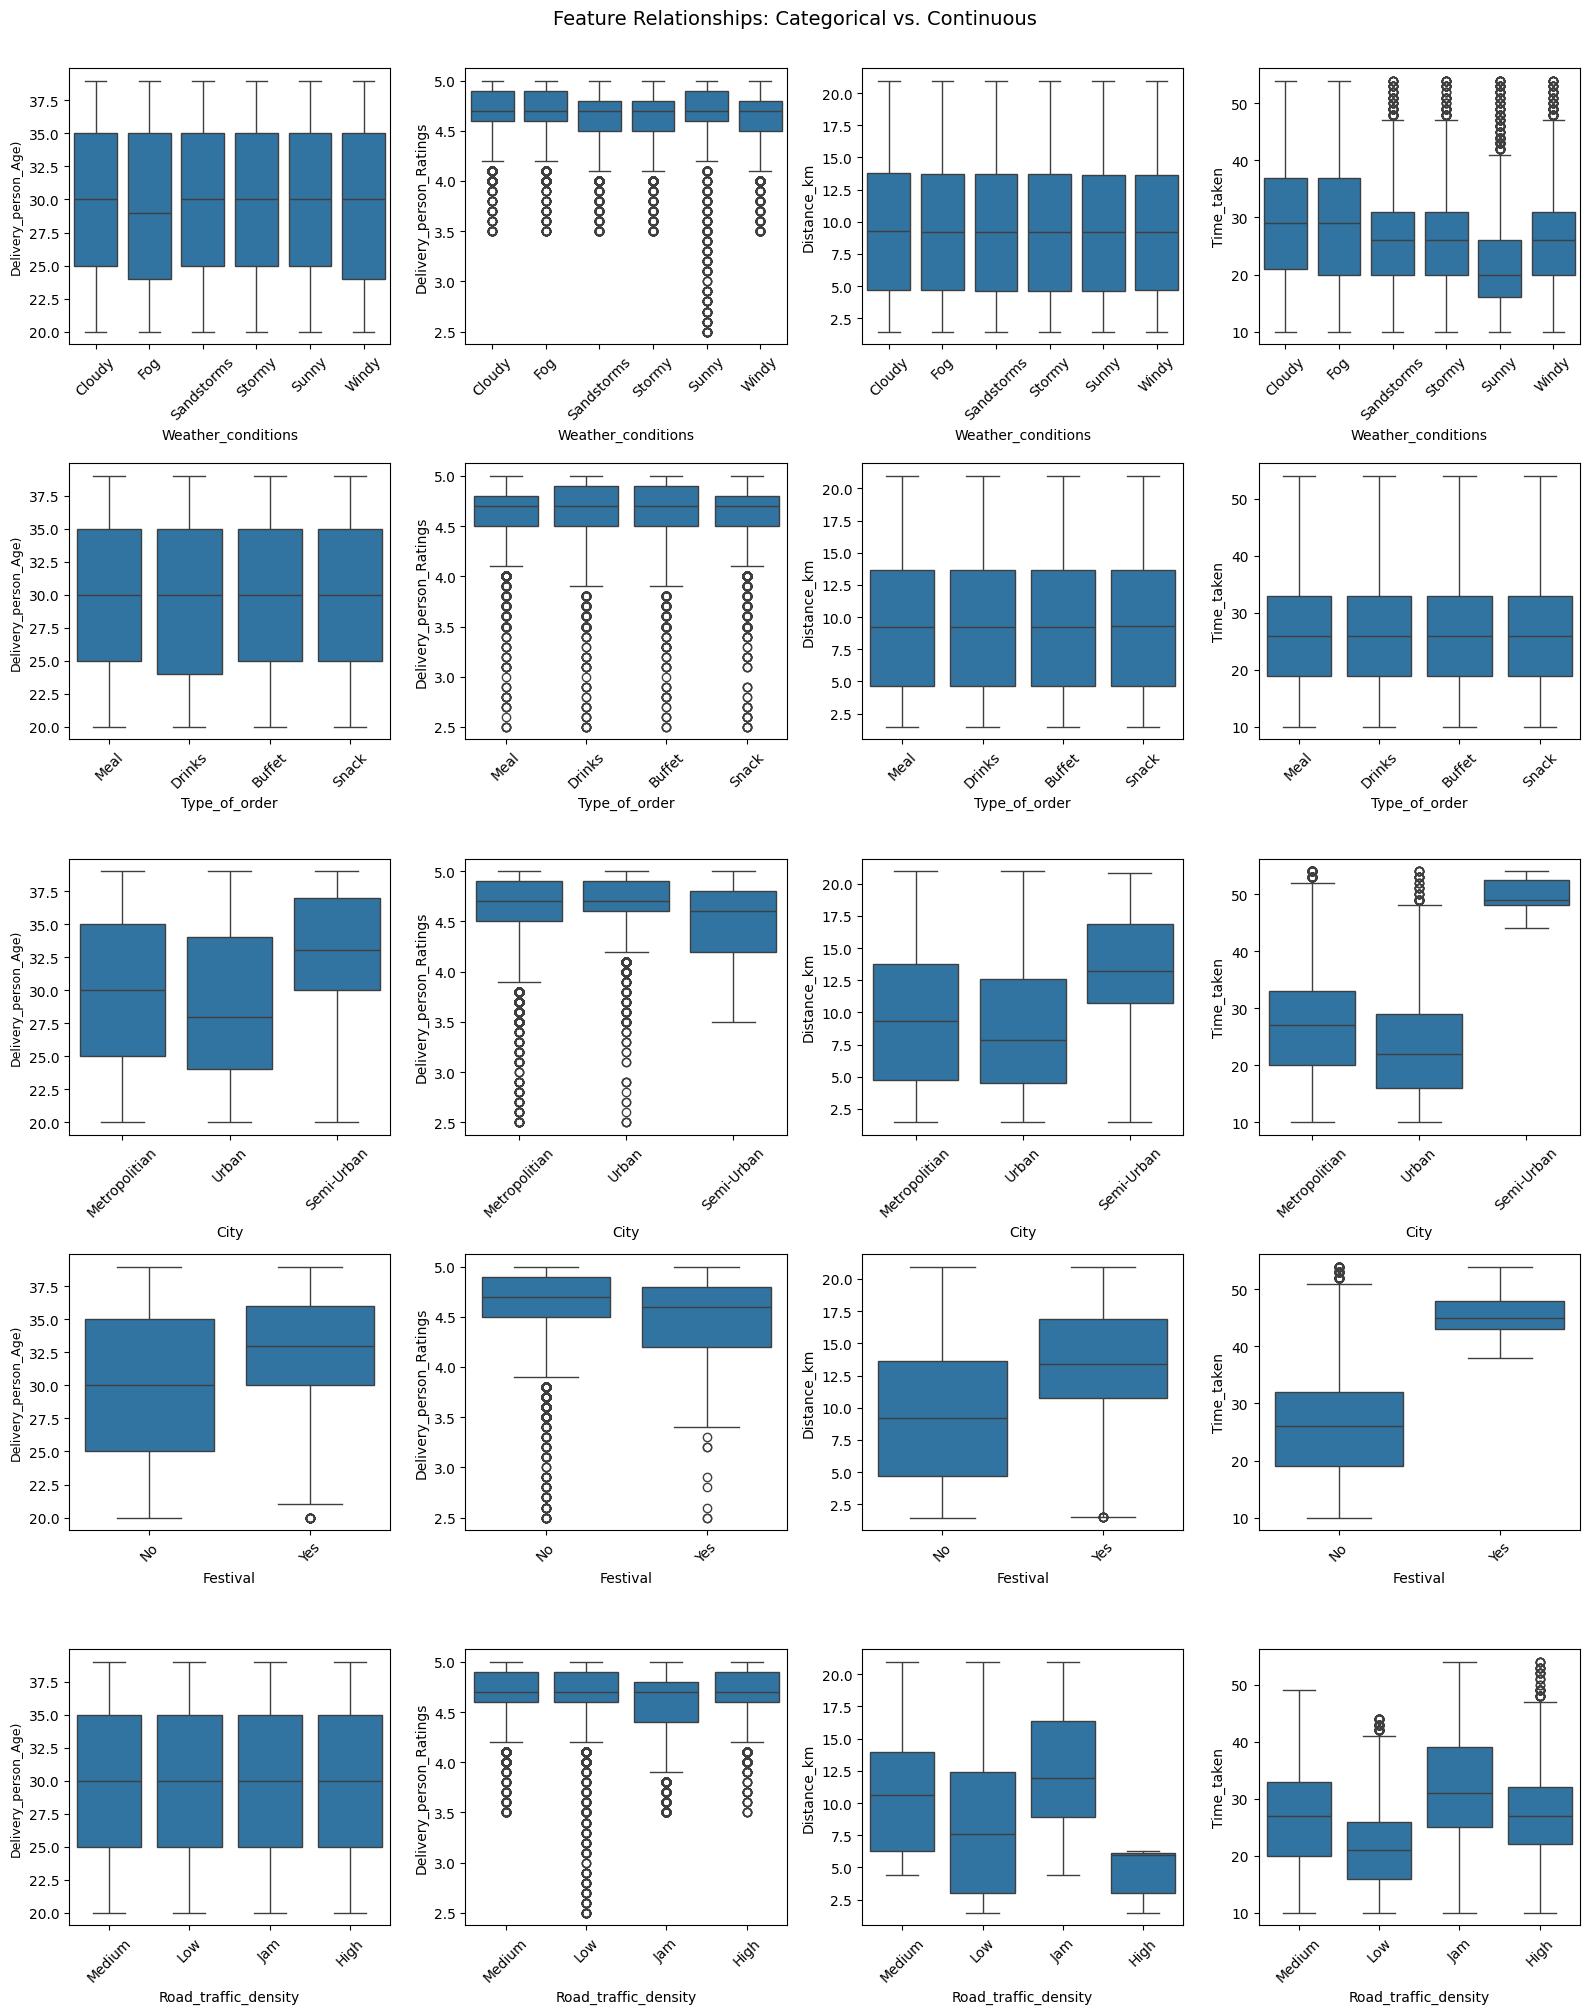

In [29]:
# Figure 3: Categorical vs Continuous (box plots, rotated labels)
fig, axs = plt.subplots(n_cat, n_cont, figsize=(4*n_cont, 4*n_cat))

for i, catcol in enumerate(categorical_cols):
    for col, ccol in enumerate(continuous_cols):
        ax = axs[i, col]
        sns.boxplot(x=catcol, y=ccol, data=train_df, ax=ax)
        ax.tick_params(axis='x', rotation=45)
        if col == 0:
            ax.set_ylabel(f'{ccol})', fontsize=9)

fig.suptitle('Feature Relationships: Categorical vs. Continuous', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

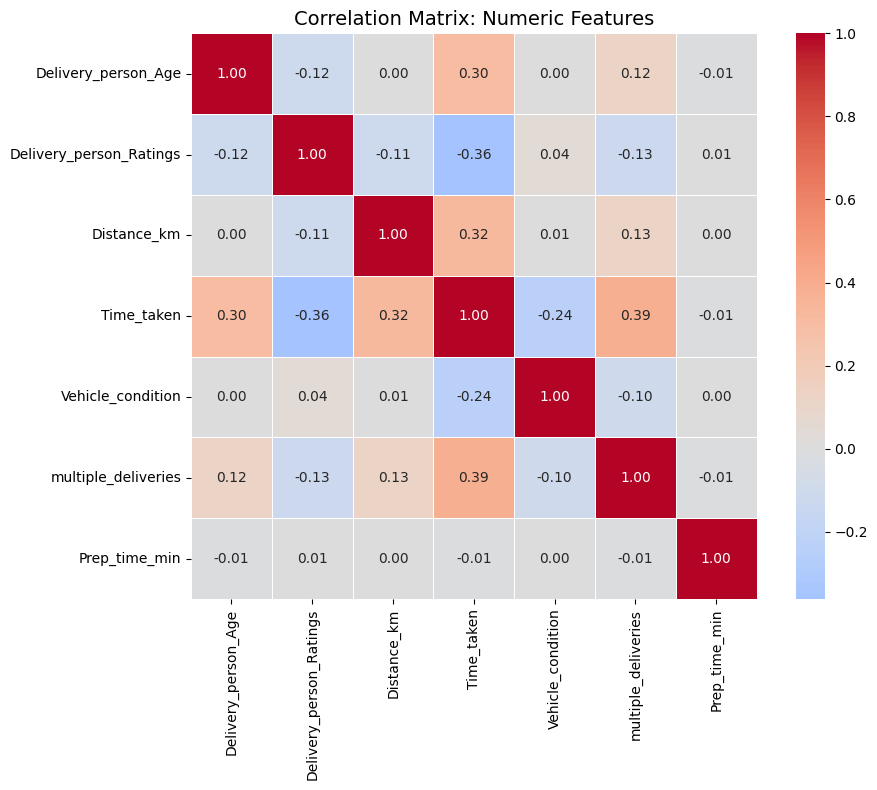

In [30]:
# 3. Correlation matrix
corr_matrix = train_df[continuous_cols + discrete_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

#### 9. Feature Encoding + Scaling

In [ ]:
# organize columns
norm_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 
                 'Distance_km', 'Prep_time_min',
                 'Vehicle_condition', 'multiple_deliveries']
onehot_cols = ['Weather_conditions', 'Type_of_order', 'Type_of_vehicle', 'City']
ordinal_cols = ['Road_traffic_density']
ordinal_order = [['Low', 'Medium', 'High', 'Jam']]

In [46]:
# 1. Binary: label encoding
for df in [X_train_clean, X_test]:
    df['Festival'] = df['Festival'].map({'No': 0, 'Yes': 1})

In [48]:
# 2. Categorical: one-hot encoding + Ordinal encoding + Scaling
preprocessor_norm = ColumnTransformer(transformers=[
    ('num', StandardScaler(), norm_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
], remainder='passthrough')

# Only One-hot encoding: categorical + Ordinal encoding (no scaling)
preprocessor_raw = ColumnTransformer(transformers=[
    ('num', 'passthrough', norm_cols), 
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
], remainder='passthrough')

# Fit each on train, transform both train/test
X_train_encoded_norm = preprocessor_norm.fit_transform(X_train_clean)
X_test_encoded_norm  = preprocessor_norm.transform(X_test)

X_train_encoded_raw = preprocessor_raw.fit_transform(X_train_clean)
X_test_encoded_raw  = preprocessor_raw.transform(X_test)

# PART 2. Model Training

### 1. Linear Regression

### 2. Tree-based

### 3. MLP

# PART 3. Model Evaluation